In [ ]:
!pip install lime
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from lime.lime_text import LimeTextExplainer
import matplotlib.pyplot as plt

In [ ]:
# Sample dataset
texts = [
    "This movie was fantastic! Really enjoyed it",
    "Terrible waste of time, awful movie",
    "Great acting and wonderful story",
    "Poor acting, boring plot, skip this one",
    "Absolutely loved this film, must watch!",
    "A bad movie, I would not recommend anyone to watch it",
    "The twist was so vague, a filthy movie.",
    "Nice one, the twist was quite good.",
    "A horrible experience, the movie was not good.",
    "Good ending, the actors did a great work."
]
labels = [1, 0, 1, 0, 1, 0, 0, 1, 0, 1]  # 1: positive, 0: negative

# Create and train pipeline
vectorizer = TfidfVectorizer(stop_words='english')
classifier = LogisticRegression()
pipeline = Pipeline([
    ('vectorizer', vectorizer),
    ('classifier', classifier)
])

X_train, X_test, y_train, y_test = train_test_split(texts, labels, test_size=0.2, random_state=42)
pipeline.fit(X_train, y_train)

# Create LIME explainer
class_names = ['negative', 'positive']
explainer = LimeTextExplainer(class_names=class_names)

def explain_prediction(text):
    # Generate explanation
    exp = explainer.explain_instance(
        text,
        pipeline.predict_proba,
        num_features=6
    )

    # Get prediction
    prob = pipeline.predict_proba([text])[0]
    predicted_class = class_names[prob.argmax()]

    # Print results
    print(f"\nText: {text}")
    print(f"Predicted class: {predicted_class}")
    print(f"Probability: {max(prob):.2f}")

    # Show explanation
    print("\nExplanation:")
    print(exp.as_list())

    # Visualize
    fig = exp.as_pyplot_figure()
    plt.tight_layout()
    plt.show()

In [ ]:
import nbformat

with open("LIME Practice File-1.ipynb", "r", encoding="utf-8") as f:
    nb = nbformat.read(f, as_version=4)

print("Notebook is valid")

FileNotFoundError: [Errno 2] No such file or directory: 'LIME Practice File-1.ipynb'


Text: This movie was so fantastic.
Predicted class: positive
Probability: 0.63

Explanation:
[(np.str_('fantastic'), 0.05464339252307356), (np.str_('movie'), -0.0536381662983862), (np.str_('This'), -0.001062789259792346), (np.str_('so'), -0.0009666232918967995), (np.str_('was'), -0.0008033197676767072)]


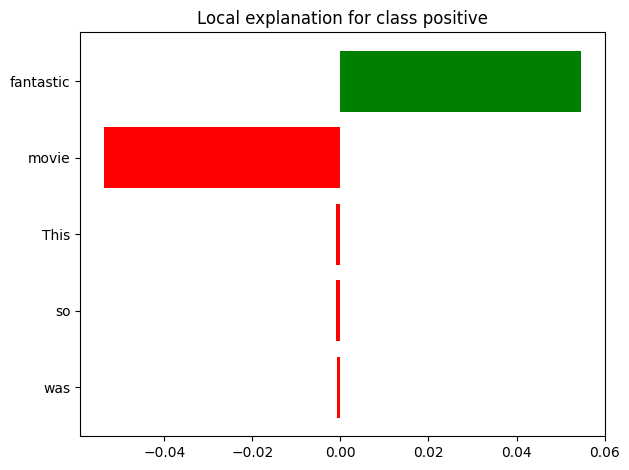

In [ ]:
# Test explanation
test_text1 = "This movie was so fantastic."
explain_prediction(test_text1)


Text: This movie was nice to watch, such a beautiful plot!
Predicted class: positive
Probability: 0.58

Explanation:
[(np.str_('nice'), 0.04187927095751833), (np.str_('movie'), -0.03334407860276549), (np.str_('plot'), -0.03295166583981146), (np.str_('watch'), -0.008145718511757546), (np.str_('to'), -0.000330644408208682), (np.str_('such'), -0.00023994644162151824)]


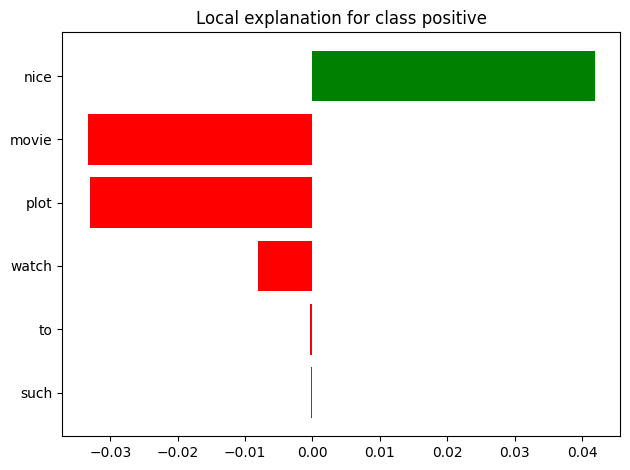

In [ ]:
test_text2 = "This movie was nice to watch, such a beautiful plot!"
explain_prediction(test_text2)


Text: I would not recommend anyone to watch it
Predicted class: positive
Probability: 0.56

Explanation:
[(np.str_('recommend'), -0.05267465357889539), (np.str_('watch'), -0.008144708438009426), (np.str_('I'), -0.0005051533621583752), (np.str_('to'), -0.00045087023561469694), (np.str_('anyone'), -0.00032003598895544654), (np.str_('not'), -0.00026895102395720375)]


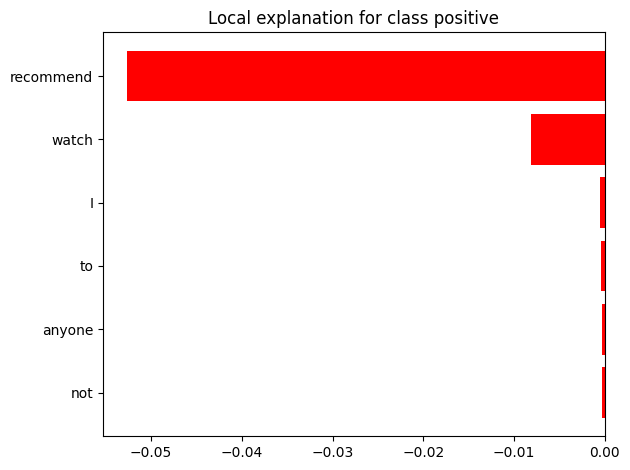

In [ ]:
test_text3 = "I would not recommend anyone to watch it"
explain_prediction(test_text3)